# Neighbourhood Pixels Lab: Image Filtering, Edge Detection, and Connectivity

This lab explores how neighbourhood pixel relationships affect image filtering, edge detection, and connectivity using a grayscale CCTV image (pika wallpaper.webp).

---

## Task 1: Load Grayscale Image & Explore Neighbourhood

- Load the image in grayscale.
- Select pixel at (120, 150) and print its 3×3 neighbourhood.
- Display the image marking the selected pixel.

3x3 Neighbourhood of pixel (120,150):
[[84 87 89]
 [89 79 61]
 [81 68 49]]


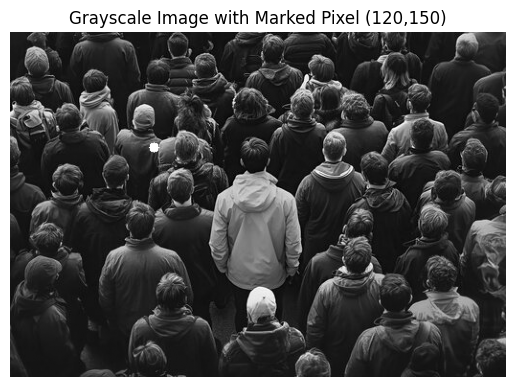

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Load grayscale image
img_gray = cv2.imread('persons.jpg', cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise Exception('Image not found!')


# Select pixel coordinates
x, y = 120, 150
neighbourhood = img_gray[x-1:x+2, y-1:y+2]
print('3x3 Neighbourhood of pixel (120,150):')
print(neighbourhood)


# Display image with marked pixel
img_marked = img_gray.copy()
cv2.circle(img_marked, (y, x), 5, (255), -1)
plt.imshow(img_marked, cmap='gray')
plt.title('Grayscale Image with Marked Pixel (120,150)')
plt.axis('off')
plt.show()

## Task 2: 4-Neighbourhood and 8-Neighbourhood Edge Detection

- Perform edge detection using 4-connected and 8-connected neighbourhoods.
- Display both results side by side.

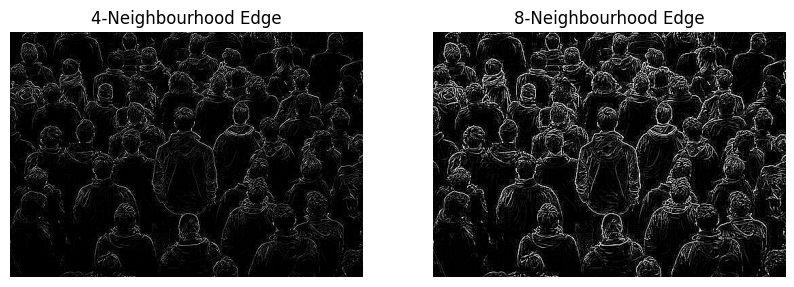

In [8]:
# 4-Neighbourhood Edge Detection Kernel
kernel_4 = np.array([[0, -1, 0],
                     [-1, 4, -1],
                     [0, -1, 0]])

edge_4 = cv2.filter2D(img_gray, -1, kernel_4)

# 8-Neighbourhood Edge Detection Kernel
kernel_8 = np.array([[-1, -1, -1],
                     [-1, 8, -1],
                     [-1, -1, -1]])

edge_8 = cv2.filter2D(img_gray, -1, kernel_8)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(edge_4, cmap='gray')
plt.title('4-Neighbourhood Edge')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(edge_8, cmap='gray')
plt.title('8-Neighbourhood Edge')
plt.axis('off')
plt.show()

## Task 3: Noise Reduction using Neighbourhood Averaging

- Add salt and pepper noise.
- Apply 3×3 mean filter to remove noise.
- Show both noisy and filtered images.

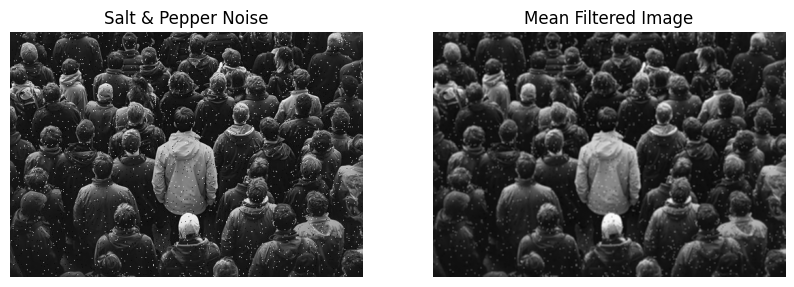

In [9]:
# Add salt and pepper noise
def add_salt_pepper_noise(image, salt_prob, pepper_prob):
    noisy = image.copy()
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)
    # Salt noise
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    # Pepper noise
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

noisy_img = add_salt_pepper_noise(img_gray, 0.01, 0.01)

# Apply 3x3 mean filter
mean_kernel = np.ones((3,3), np.float32) / 9
filtered_img = cv2.filter2D(noisy_img, -1, mean_kernel)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(noisy_img, cmap='gray')
plt.title('Salt & Pepper Noise')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(filtered_img, cmap='gray')
plt.title('Mean Filtered Image')
plt.axis('off')
plt.show()